In [1]:
import sklearn
import pandas as pd
import numpy as np
import matplotlib
import seaborn as sns

print(f"✅ scikit-learn: {sklearn.__version__}")
print(f"✅ pandas: {pd.__version__}")
print(f"✅ numpy: {np.__version__}")
print(f"✅ matplotlib: {matplotlib.__version__}")
print("✅ Todos los paquetes listos")

✅ scikit-learn: 1.6.1
✅ pandas: 2.2.2
✅ numpy: 2.0.2
✅ matplotlib: 3.10.0
✅ Todos los paquetes listos


In [2]:
# ============================================================
# CELDA 1: Dataset Movistar Perú — ejecutar sin modificar
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(2026)
N = 5000

planes = ["Básico 29", "Estándar 39", "Plus 59", "Premium 79", "Elite 99"]
regiones = ["Lima", "Arequipa", "Cusco", "Trujillo", "Piura",
            "Iquitos", "Tacna", "Huancayo"]
canales = ["Tienda física", "App móvil", "Web", "Call center", "Promotor"]

df = pd.DataFrame({
    "id_cliente":       [f"MOV{i:06d}" for i in range(1, N+1)],
    "plan":             np.random.choice(planes, N, p=[0.3, 0.25, 0.2, 0.15, 0.1]),
    "precio_plan":      np.random.choice([29, 39, 59, 79, 99], N, p=[0.3, 0.25, 0.2, 0.15, 0.1]),
    "meses_cliente":    np.random.randint(1, 85, N),
    "gb_consumidos_mes":np.round(np.random.exponential(18, N), 1),
    "llamadas_mes":     np.random.poisson(45, N),
    "quejas_6meses":    np.random.poisson(0.7, N),
    "pagos_tardios":    np.random.randint(0, 8, N),
    "num_productos":    np.random.randint(1, 6, N),
    "region":           np.random.choice(regiones, N, p=[0.45, 0.10, 0.08, 0.10, 0.08, 0.07, 0.05, 0.07]),
    "canal_adquisicion":np.random.choice(canales, N),
    "tiene_descuento":  np.random.choice([0, 1], N, p=[0.65, 0.35]),
})

# Variable objetivo: churn (probabilidad basada en comportamiento real)
prob_churn = (
    0.03 +
    df["quejas_6meses"] * 0.12 +
    df["pagos_tardios"] * 0.06 -
    df["meses_cliente"] * 0.002 -
    df["num_productos"] * 0.03 -
    df["tiene_descuento"] * 0.05 +
    (df["precio_plan"] == 29).astype(int) * 0.04
).clip(0.01, 0.92)

# Introducir sesgo geográfico: clientes de Lima tienen 30% menos probabilidad de churn
# (representan más datos de calidad en el sistema histórico)
prob_churn_ajustada = prob_churn.copy()
mask_lima = df["region"] == "Lima"
prob_churn_ajustada[mask_lima] = prob_churn[mask_lima] * 0.70
prob_churn_ajustada[~mask_lima] = prob_churn[~mask_lima] * 1.10

df["churn"] = (np.random.random(N) < prob_churn_ajustada).astype(int)

print(f"✅ Dataset Movistar Perú: {len(df):,} clientes")
print(f"📊 Churn rate global: {df['churn'].mean():.1%}")
print(f"📊 Churn rate Lima: {df[mask_lima]['churn'].mean():.1%}")
print(f"📊 Churn rate otras regiones: {df[~mask_lima]['churn'].mean():.1%}")
print(f"\nEstructura del dataset:")
print(df.dtypes)
df.head()

✅ Dataset Movistar Perú: 5,000 clientes
📊 Churn rate global: 14.5%
📊 Churn rate Lima: 11.6%
📊 Churn rate otras regiones: 16.8%

Estructura del dataset:
id_cliente            object
plan                  object
precio_plan            int64
meses_cliente          int64
gb_consumidos_mes    float64
llamadas_mes           int64
quejas_6meses          int64
pagos_tardios          int64
num_productos          int64
region                object
canal_adquisicion     object
tiene_descuento        int64
churn                  int64
dtype: object


,id_cliente,plan,precio_plan,meses_cliente,gb_consumidos_mes,llamadas_mes,quejas_6meses,pagos_tardios,num_productos,region,canal_adquisicion,tiene_descuento,churn
0,MOV000001,Básico 29,39,8,31.8,45,0,2,1,Cusco,Tienda física,0,0
1,MOV000002,Estándar 39,39,62,36.2,43,0,3,4,Huancayo,Web,0,0
2,MOV000003,Elite 99,39,84,29.8,44,0,4,4,Lima,Web,1,0
3,MOV000004,Básico 29,39,3,18.2,52,1,0,3,Tacna,Promotor,0,0
4,MOV000005,Estándar 39,79,10,11.1,43,1,1,1,Tacna,Promotor,1,0


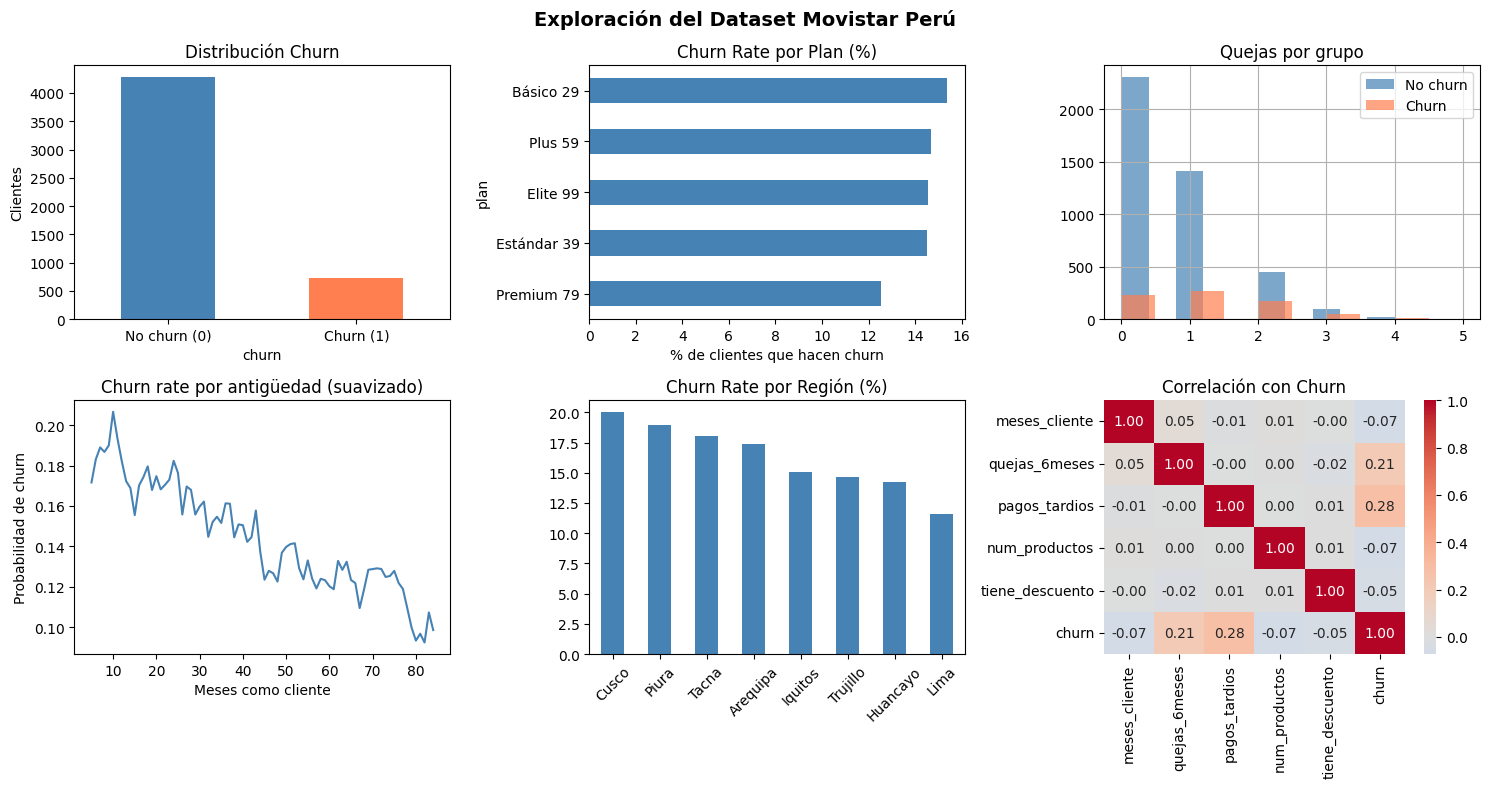

✅ EDA guardado como movistar_eda.png


In [3]:
# ============================================================
# CELDA 2: Análisis Exploratorio de Datos (EDA)
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Exploración del Dataset Movistar Perú", fontsize=14, fontweight='bold')

# Distribución de la variable objetivo
df["churn"].value_counts().plot(kind="bar", ax=axes[0,0], color=["steelblue", "coral"])
axes[0,0].set_title("Distribución Churn")
axes[0,0].set_xticklabels(["No churn (0)", "Churn (1)"], rotation=0)
axes[0,0].set_ylabel("Clientes")

# Churn rate por plan
churn_plan = df.groupby("plan")["churn"].mean() * 100
churn_plan.sort_values().plot(kind="barh", ax=axes[0,1], color="steelblue")
axes[0,1].set_title("Churn Rate por Plan (%)")
axes[0,1].set_xlabel("% de clientes que hacen churn")

# Distribución de quejas por grupo (churn vs no churn)
df[df["churn"]==0]["quejas_6meses"].hist(ax=axes[0,2], alpha=0.7, label="No churn", color="steelblue")
df[df["churn"]==1]["quejas_6meses"].hist(ax=axes[0,2], alpha=0.7, label="Churn", color="coral")
axes[0,2].set_title("Quejas por grupo")
axes[0,2].legend()

# Meses como cliente vs churn
df.groupby("meses_cliente")["churn"].mean().rolling(5).mean().plot(ax=axes[1,0], color="steelblue")
axes[1,0].set_title("Churn rate por antigüedad (suavizado)")
axes[1,0].set_xlabel("Meses como cliente")
axes[1,0].set_ylabel("Probabilidad de churn")

# Churn por región
churn_region = df.groupby("region")["churn"].mean() * 100
churn_region.sort_values(ascending=False).plot(kind="bar", ax=axes[1,1], color="steelblue")
axes[1,1].set_title("Churn Rate por Región (%)")
axes[1,1].set_xlabel("")
axes[1,1].tick_params(axis='x', rotation=45)

# Correlación de variables numéricas
correlaciones = df[["meses_cliente", "quejas_6meses", "pagos_tardios",
                     "num_productos", "tiene_descuento", "churn"]].corr()
sns.heatmap(correlaciones, annot=True, fmt=".2f", cmap="coolwarm",
            ax=axes[1,2], center=0)
axes[1,2].set_title("Correlación con Churn")

plt.tight_layout()
plt.savefig("movistar_eda.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA guardado como movistar_eda.png")

In [4]:
# ============================================================
# CELDA 3: Preprocesamiento — COMPLETA LOS ___
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Codificar variables categóricas (texto → número)
df_modelo = df.copy()

# Encoding de columnas categóricas
for col in ["plan", "region", "canal_adquisicion"]:
    le = LabelEncoder()
    df_modelo[col + "_cod"] = le.fit_transform(df_modelo[col])

# Seleccionar features (X) y variable objetivo (y)
features = ["precio_plan", "meses_cliente", "gb_consumidos_mes",
            "llamadas_mes", "quejas_6meses", "pagos_tardios",
            "num_productos", "tiene_descuento",
            "plan_cod", "region_cod", "canal_adquisicion_cod"]

X = df_modelo[features]
y = df_modelo["___"]           # ← COMPLETA: variable objetivo

print(f"Features utilizadas: {features}")
print(f"Shape de X: {X.shape}")
print(f"Distribución de y: {y.value_counts().to_dict()}")

# Dividir en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=___,             # ← COMPLETA: proporción de prueba
    random_state=2026,
    stratify=y                 # mantiene proporción de churn en ambos sets
)
print(f"\nEntrenamiento: {len(X_train):,} clientes")
print(f"Prueba: {len(X_test):,} clientes")

# Normalizar: escalar al mismo rango
# IMPORTANTE: fit SOLO en entrenamiento para no espiar los datos de prueba
scaler = ___()                 # ← COMPLETA: clase del escalador
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # solo transform, no fit

print("\n✅ Preprocesamiento completo")
print(f"Media de X_train_scaled: {X_train_scaled.mean():.4f} (debe ser ≈ 0)")
print(f"Std  de X_train_scaled: {X_train_scaled.std():.4f} (debe ser ≈ 1)")

KeyError: '___'

In [5]:
# ============================================================
# CELDA 3: Preprocesamiento
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Copiar el dataset original
df_modelo = df.copy()

# Convertir columnas de texto a valores numéricos
for col in ["plan", "region", "canal_adquisicion"]:
    le = LabelEncoder()
    df_modelo[col + "_cod"] = le.fit_transform(df_modelo[col])

# Variables que utilizará el modelo
features = [
    "precio_plan",
    "meses_cliente",
    "gb_consumidos_mes",
    "llamadas_mes",
    "quejas_6meses",
    "pagos_tardios",
    "num_productos",
    "tiene_descuento",
    "plan_cod",
    "region_cod",
    "canal_adquisicion_cod"
]

# X contiene las variables de entrada
X = df_modelo[features]

# y contiene la variable que queremos predecir
y = df_modelo["churn"]

print(f"Features utilizadas: {features}")
print(f"Shape de X: {X.shape}")
print(f"Distribución de y: {y.value_counts().to_dict()}")

# Separar 80% para entrenamiento y 20% para prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=2026,
    stratify=y
)

print(f"\nEntrenamiento: {len(X_train):,} clientes")
print(f"Prueba: {len(X_test):,} clientes")

# Normalizar las variables
scaler = StandardScaler()

# El escalador aprende únicamente con los datos de entrenamiento
X_train_scaled = scaler.fit_transform(X_train)

# A los datos de prueba solo se les aplica la transformación
X_test_scaled = scaler.transform(X_test)

print("\n✅ Preprocesamiento completo")
print(
    f"Media de X_train_scaled: "
    f"{X_train_scaled.mean():.4f} (debe ser ≈ 0)"
)
print(
    f"Std de X_train_scaled: "
    f"{X_train_scaled.std():.4f} (debe ser ≈ 1)"
)

Features utilizadas: ['precio_plan', 'meses_cliente', 'gb_consumidos_mes', 'llamadas_mes', 'quejas_6meses', 'pagos_tardios', 'num_productos', 'tiene_descuento', 'plan_cod', 'region_cod', 'canal_adquisicion_cod']
Shape de X: (5000, 11)
Distribución de y: {0: 4275, 1: 725}

Entrenamiento: 4,000 clientes
Prueba: 1,000 clientes

✅ Preprocesamiento completo
Media de X_train_scaled: -0.0000 (debe ser ≈ 0)
Std de X_train_scaled: 1.0000 (debe ser ≈ 1)


In [6]:
# ============================================================
# CELDA 4: Entrenamiento y comparación de modelos
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    f1_score,
    roc_auc_score,
    accuracy_score
)

# Definir los tres modelos
modelos = {
    "Regresión Logística": LogisticRegression(
        random_state=2026,
        max_iter=1000,
        class_weight="balanced"
    ),

    "Árbol de Decisión": DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=20,
        random_state=2026
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=8,
        random_state=2026,
        class_weight="balanced"
    )
}

resultados = {}

for nombre, modelo in modelos.items():

    # Entrenar el modelo
    modelo.fit(X_train_scaled, y_train)

    # Predicción de clase
    y_pred = modelo.predict(X_test_scaled)

    # Probabilidad de churn
    y_prob = modelo.predict_proba(X_test_scaled)[:, 1]

    # Guardar métricas y resultados
    resultados[nombre] = {
        "accuracy": round(
            accuracy_score(y_test, y_pred),
            4
        ),
        "f1_churn": round(
            f1_score(y_test, y_pred, zero_division=0),
            4
        ),
        "auc_roc": round(
            roc_auc_score(y_test, y_prob),
            4
        ),
        "modelo": modelo,
        "y_pred": y_pred
    }

    print(f"\n=== {nombre} ===")

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["Se queda", "Hace churn"],
            zero_division=0
        )
    )

# Tabla comparativa
print("\n" + "=" * 55)
print("TABLA COMPARATIVA DE MODELOS")
print("=" * 55)

print(
    f"{'Modelo':<25} "
    f"{'Accuracy':>9} "
    f"{'F1-Churn':>9} "
    f"{'AUC-ROC':>9}"
)

print("-" * 55)

for nombre, resultado in resultados.items():
    print(
        f"{nombre:<25} "
        f"{resultado['accuracy']:>9.4f} "
        f"{resultado['f1_churn']:>9.4f} "
        f"{resultado['auc_roc']:>9.4f}"
    )


=== Regresión Logística ===
              precision    recall  f1-score   support

    Se queda       0.93      0.71      0.81       855
  Hace churn       0.29      0.70      0.41       145

    accuracy                           0.71      1000
   macro avg       0.61      0.71      0.61      1000
weighted avg       0.84      0.71      0.75      1000


=== Árbol de Decisión ===
              precision    recall  f1-score   support

    Se queda       0.86      0.98      0.91       855
  Hace churn       0.30      0.06      0.10       145

    accuracy                           0.84      1000
   macro avg       0.58      0.52      0.51      1000
weighted avg       0.78      0.84      0.80      1000


=== Random Forest ===
              precision    recall  f1-score   support

    Se queda       0.90      0.81      0.86       855
  Hace churn       0.31      0.48      0.37       145

    accuracy                           0.77      1000
   macro avg       0.60      0.65      0.62      

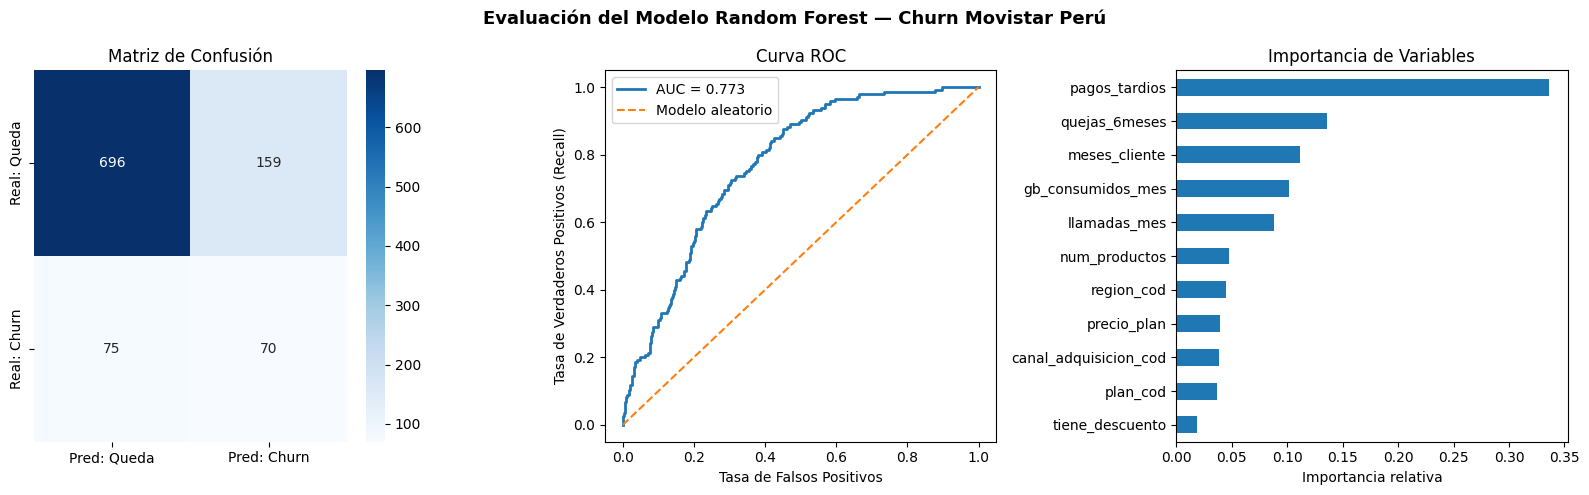

✅ Gráficos guardados como movistar_evaluacion.png


In [7]:
# ============================================================
# CELDA 5: Visualizar el mejor modelo
# ============================================================

from sklearn.metrics import confusion_matrix, roc_curve
import warnings

warnings.filterwarnings("ignore")

# Tomar Random Forest como mejor modelo
mejor_modelo = resultados["Random Forest"]["modelo"]
y_pred_mejor = resultados["Random Forest"]["y_pred"]
y_prob_mejor = mejor_modelo.predict_proba(X_test_scaled)[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

fig.suptitle(
    "Evaluación del Modelo Random Forest — Churn Movistar Perú",
    fontsize=13,
    fontweight="bold"
)

# 1. Matriz de confusión
cm = confusion_matrix(y_test, y_pred_mejor)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0],
    xticklabels=["Pred: Queda", "Pred: Churn"],
    yticklabels=["Real: Queda", "Real: Churn"]
)

axes[0].set_title("Matriz de Confusión")

# 2. Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_mejor)
auc_val = resultados["Random Forest"]["auc_roc"]

axes[1].plot(
    fpr,
    tpr,
    lw=2,
    label=f"AUC = {auc_val:.3f}"
)

axes[1].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Modelo aleatorio"
)

axes[1].set_xlabel("Tasa de Falsos Positivos")
axes[1].set_ylabel("Tasa de Verdaderos Positivos (Recall)")
axes[1].set_title("Curva ROC")
axes[1].legend()

# 3. Importancia de variables
importancias = pd.Series(
    mejor_modelo.feature_importances_,
    index=features
).sort_values(ascending=True)

importancias.plot(
    kind="barh",
    ax=axes[2]
)

axes[2].set_title("Importancia de Variables")
axes[2].set_xlabel("Importancia relativa")

plt.tight_layout()

plt.savefig(
    "movistar_evaluacion.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("✅ Gráficos guardados como movistar_evaluacion.png")

In [8]:
# ============================================================
# CELDA 6: ANÁLISIS DE EQUIDAD (FAIRNESS)
# ============================================================

print("=" * 60)
print("ANÁLISIS DE EQUIDAD (FAIRNESS) — MOVISTAR PERÚ")
print("=" * 60)

# Agregar predicciones al dataset de prueba
X_test_df = pd.DataFrame(
    X_test_scaled,
    columns=features,
    index=X_test.index
)

df_eval = df.loc[X_test.index].copy()

df_eval["y_pred"] = y_pred_mejor
df_eval["y_prob"] = y_prob_mejor

print("\n📊 MÉTRICAS POR REGIÓN:")
print(f"{'Región':<15} {'N clientes':>12} {'Churn real':>12} {'F1-Score':>10} {'AUC-ROC':>10}")
print("-" * 60)

metricas_region = {}

for region in sorted(df_eval["region"].unique()):

    mask = df_eval["region"] == region

    y_real_r = y_test[mask]
    y_pred_r = df_eval.loc[mask, "y_pred"]
    y_prob_r = df_eval.loc[mask, "y_prob"]

    n = mask.sum()

    f1 = f1_score(
        y_real_r,
        y_pred_r,
        zero_division=0
    )

    auc = roc_auc_score(
        y_real_r,
        y_prob_r
    ) if y_real_r.sum() > 0 else float("nan")

    churn_real = y_real_r.mean()

    metricas_region[region] = {
        "f1": f1,
        "auc": auc,
        "n": n,
        "churn_real": churn_real
    }

    flag = "⚠️" if f1 < 0.30 else "✅"

    print(
        f"{region:<15}"
        f"{n:>12,}"
        f"{churn_real:>11.1%}"
        f"{f1:>10.3f}"
        f"{auc:>10.3f}"
        f" {flag}"
    )

# Comparar desempeño entre regiones
f1_values = [v["f1"] for v in metricas_region.values()]

disparidad = max(f1_values) - min(f1_values)

print(f"\n📊 Disparidad máxima de F1 entre regiones: {disparidad:.3f}")

if disparidad > 0.15:
    print("⚠️ ALERTA: El modelo no funciona igual para todas las regiones.")
    print("Puede existir un sesgo geográfico.")
else:
    print("✅ El modelo funciona de forma similar en todas las regiones.")

ANÁLISIS DE EQUIDAD (FAIRNESS) — MOVISTAR PERÚ

📊 MÉTRICAS POR REGIÓN:
Región            N clientes   Churn real   F1-Score    AUC-ROC
------------------------------------------------------------
Arequipa                103      16.5%     0.511     0.802 ✅
Cusco                    82      20.7%     0.514     0.816 ✅
Huancayo                 64      12.5%     0.345     0.730 ✅
Iquitos                  79      12.7%     0.333     0.777 ✅
Lima                    432      12.0%     0.311     0.770 ✅
Piura                    74      18.9%     0.483     0.832 ✅
Tacna                    52      25.0%     0.417     0.773 ✅
Trujillo                114      12.3%     0.250     0.717 ⚠️

📊 Disparidad máxima de F1 entre regiones: 0.264
⚠️ ALERTA: El modelo no funciona igual para todas las regiones.
Puede existir un sesgo geográfico.


In [9]:
# ============================================================
# CELDA 7: DESAFÍO
# ============================================================

print("=== ESTRATEGIA DE MITIGACIÓN DE SESGO ===")

peor_region = min(metricas_region, key=lambda r: metricas_region[r]["f1"])
mejor_region = max(metricas_region, key=lambda r: metricas_region[r]["f1"])

print(f"Región con peor F1: {peor_region} ({metricas_region[peor_region]['f1']:.3f})")
print(f"Región con mejor F1: {mejor_region} ({metricas_region[mejor_region]['f1']:.3f})")

threshold_ajustado = 0.35

mask_peor = df_eval["region"] == peor_region

y_real_peor = y_test[mask_peor]
y_prob_peor = df_eval.loc[mask_peor, "y_prob"]

y_pred_normal = (y_prob_peor >= 0.50).astype(int)
y_pred_ajustado = (y_prob_peor >= threshold_ajustado).astype(int)

f1_normal = f1_score(y_real_peor, y_pred_normal, zero_division=0)
f1_ajustado = f1_score(y_real_peor, y_pred_ajustado, zero_division=0)

print(f"\nResultados para {peor_region}")
print(f"F1 normal: {f1_normal:.3f}")
print(f"F1 ajustado: {f1_ajustado:.3f}")
print(f"Mejora: {f1_ajustado - f1_normal:+.3f}")

print("""
¿Por qué bajar el threshold mejora el Recall pero reduce la Precision?

Respuesta:
Al disminuir el threshold, el modelo clasifica como churn a más clientes.
Esto permite detectar más casos reales (mayor Recall), pero también genera
más falsos positivos, reduciendo la Precision.
""")

=== ESTRATEGIA DE MITIGACIÓN DE SESGO ===
Región con peor F1: Trujillo (0.250)
Región con mejor F1: Cusco (0.514)

Resultados para Trujillo
F1 normal: 0.250
F1 ajustado: 0.302
Mejora: +0.052

¿Por qué bajar el threshold mejora el Recall pero reduce la Precision?

Respuesta:
Al disminuir el threshold, el modelo clasifica como churn a más clientes.
Esto permite detectar más casos reales (mayor Recall), pero también genera
más falsos positivos, reduciendo la Precision.

